# M11.2 — Geocentric time and detector antenna response

## Objective

M10 uses a fixed geocentric coalescence time for all synthetic events.

However, the response of an Earth-based interferometer depends on the orientation of the detector relative to the source at the event time. Therefore, for fixed source coordinates $(\alpha,\delta)$ and polarization $\psi$, changing the geocentric GPS time changes both:

- the detector antenna response;
- the propagation delay between the geocenter and each detector.

For detector $I$,

$$
h_I(t)
=
F_I^+(\alpha,\delta,\psi,t_{\rm geo})\,h_+(t-\tau_I)
+
F_I^\times(\alpha,\delta,\psi,t_{\rm geo})\,h_\times(t-\tau_I).
$$

The purpose of M11.2 is to quantify this dependence before changing the simulation-time sampling policy.

## 1. Hypotheses

### H1 — fixed-source time dependence

For a source with fixed sky position and polarization,

$$
(\alpha,\delta,\psi)=\mathrm{constant},
$$

changing $t_{\rm geo}$ should modify:

$$
F_I^+, \qquad F_I^\times, \qquad \tau_I,
$$

and therefore the relative detector response.

### H2 — sidereal periodicity

Because the effect is driven primarily by Earth rotation, the response should vary approximately periodically over one sidereal day.

### H3 — population-level subtlety

If right ascension is already sampled uniformly over

$$
\alpha\in[0,2\pi),
$$

then a fixed $t_{\rm geo}$ may already produce a broad marginal distribution of antenna responses.

Therefore, varying $t_{\rm geo}$ is physically better motivated, but it is not assumed in advance that it will substantially alter the marginal training distribution.

This notebook first tests H1 and H2 using a fixed source. Population-level effects will be studied only after the single-source geometry is understood.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycbc.detector import Detector

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector

## 2. Controlled source configuration

The intrinsic and extrinsic source parameters are held fixed throughout the first experiment.

Only the geocentric event time is varied.

A moderate-mass BBH is used because M11.2 concerns detector geometry rather than waveform duration. The waveform itself is generated only once; changing $t_{\rm geo}$ changes the detector projection, not the source-frame waveform.

In [4]:
config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",
)

params = CBCParameters(
    mass_1=30.0,
    mass_2=30.0,
    distance=500.0,
    inclination=1.0,
    ra=1.0,
    dec=0.3,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.5,
)

DETECTORS = ["H1", "L1", "V1"]

T0 = 1126259462.0

SIDEREAL_DAY = 86164.0905  # s

## 3. Source-frame waveform

The source-frame waveform does not depend on geocentric time.

It is therefore generated once and reused for every detector-time projection. This ensures that any observed difference is caused exclusively by detector geometry.

In [5]:
waveform_generator = WaveformGenerator(config)
projector = DetectorProjector(DETECTORS)

waveform = waveform_generator.generate(params)

print("Waveform duration:", waveform.metadata.duration, "s")
print("n_samples:", waveform.metadata.n_samples)
print("start_time:", waveform.metadata.start_time)
print("end_time:", waveform.metadata.end_time)

Waveform duration: 0.375732421875 s
n_samples: 1539
start_time: -0.261318205
end_time: 0.11441421687499997


## 4. Geocentric-time sweep

The same source is projected at multiple geocentric times spanning one sidereal day:

$$
t_k = t_0 + \Delta t_k,
\qquad
0 \le \Delta t_k \le T_{\rm sidereal}.
$$

The source coordinates and waveform remain fixed.

We record:

$$
F_I^+,\quad
F_I^\times,\quad
F_{I,\mathrm{rss}}
=
\sqrt{(F_I^+)^2+(F_I^\times)^2},
$$

together with detector delays relative to the geocenter.

In [6]:
N_TIMES = 97

time_offsets = np.linspace(
    0.0,
    SIDEREAL_DAY,
    N_TIMES,
)

geocentric_times = T0 + time_offsets

detector_objects = {
    name: Detector(name)
    for name in DETECTORS
}

In [9]:
rows = []

for offset, t_geo in zip(
    time_offsets,
    geocentric_times,
):

    delays = projector.compute_time_delays(
        parameters=params,
        geocentric_coalescence_time=t_geo,
    )

    for ifo, detector in detector_objects.items():

        fp, fc = detector.antenna_pattern(
            right_ascension=params.ra,
            declination=params.dec,
            polarization=params.polarization_angle,
            t_gps=t_geo,
        )

        rows.append({
            "time_offset_s": offset,
            "time_offset_h": offset / 3600.0,
            "t_geo": t_geo,
            "ifo": ifo,
            "F_plus": float(fp),
            "F_cross": float(fc),
            "F_rss": float(
                np.sqrt(fp**2 + fc**2)
            ),
            "delay_s": delays[ifo],
        })

df_geometry = pd.DataFrame(rows)

df_geometry.head(12)

,time_offset_s,time_offset_h,t_geo,ifo,F_plus,F_cross,F_rss,delay_s
0,0.000000,0.000000,1.126259e+09,H1,0.004979,0.763893,0.763909,-0.015890
1,0.000000,0.000000,1.126259e+09,L1,0.054440,-0.965273,0.966807,-0.020552
2,0.000000,0.000000,1.126259e+09,V1,0.392857,0.320804,0.507199,-0.003299
3,897.542609,0.249317,1.126260e+09,H1,0.060678,0.786473,0.788811,-0.016404
4,897.542609,0.249317,1.126260e+09,L1,0.003086,-0.971830,0.971835,-0.020661
5,897.542609,0.249317,1.126260e+09,V1,0.409543,0.295993,0.505309,-0.002340
6,1795.085219,0.498635,1.126261e+09,H1,0.118342,0.801624,0.810312,-0.016867
7,1795.085219,0.498635,1.126261e+09,L1,-0.048651,-0.972049,0.973266,-0.020695
8,1795.085219,0.498635,1.126261e+09,V1,0.420464,0.274307,0.502030,-0.001389
9,2692.627828,0.747952,1.126262e+09,H1,0.177359,0.809190,0.828399,-0.017278


## 5. Basic geometry checks

Before interpreting the time dependence, verify that all antenna factors and delays are finite and physically bounded.

For an L-shaped interferometer,

$$
|F_+|\le1,
\qquad
|F_\times|\le1.
$$

Detector delays relative to the Earth center must remain of order milliseconds.

In [10]:
assert np.all(
    np.isfinite(
        df_geometry[
            ["F_plus", "F_cross", "F_rss", "delay_s"]
        ].to_numpy()
    )
)

assert np.all(
    np.abs(df_geometry["F_plus"]) <= 1.0 + 1e-12
)

assert np.all(
    np.abs(df_geometry["F_cross"]) <= 1.0 + 1e-12
)

print(
    df_geometry
    .groupby("ifo")[
        ["F_plus", "F_cross", "F_rss", "delay_s"]
    ]
    .agg(["min", "max"])
)

       F_plus             F_cross               F_rss             delay_s  \
          min       max       min       max       min       max       min   
ifo                                                                         
H1  -0.552644  0.770926 -0.409902  0.809190  0.191056  0.873274 -0.018557   
L1  -0.502138  0.650779 -0.972049  0.079734  0.105607  0.973266 -0.020695   
V1  -0.876129  0.425750 -0.452691  0.644337  0.018262  0.898780 -0.019051   

               
          max  
ifo            
H1   0.009487  
L1   0.014338  
V1   0.010418  


## 6. Time dependence of the antenna response

If the fixed-time M10 setup suppresses genuine detector-orientation variability, the antenna factors should change substantially over the sidereal-day sweep.

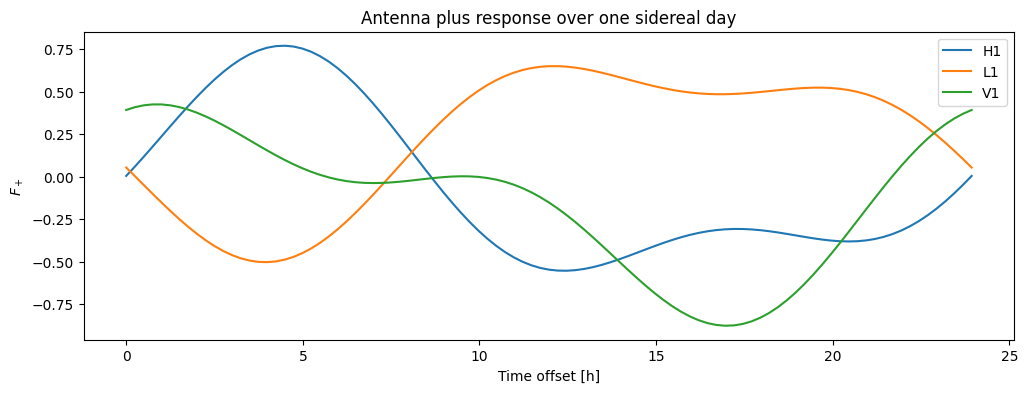

In [13]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:
    d = df_geometry[
        df_geometry["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        d["F_plus"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel(r"$F_+$")
plt.title("Antenna plus response over one sidereal day")
plt.legend()
plt.show()

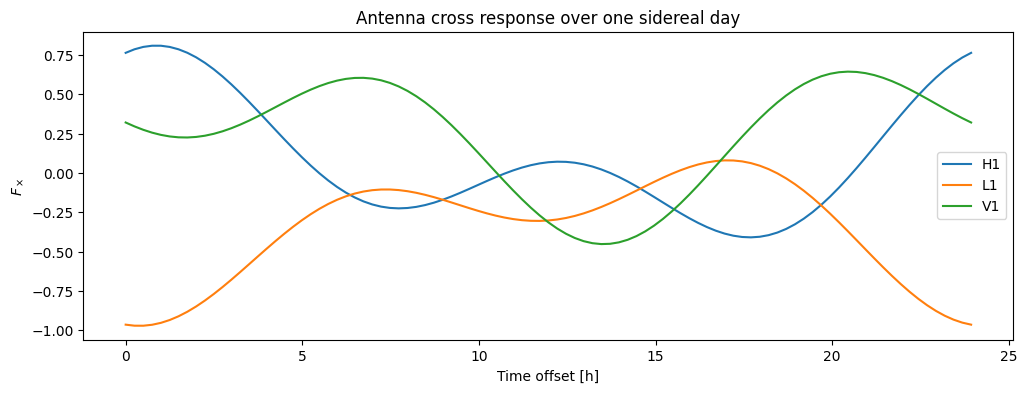

In [14]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:
    d = df_geometry[
        df_geometry["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        d["F_cross"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel(r"$F_\times$")
plt.title("Antenna cross response over one sidereal day")
plt.legend()
plt.show()

## 7. Effective antenna magnitude

The combination

$$
F_{\rm rss}
=
\sqrt{F_+^2+F_\times^2}
$$

provides a simple polarization-independent measure of how strongly the detector geometry couples to the two GW polarizations.

It does not by itself equal the observed signal amplitude, because the source inclination determines the relative amplitudes of $h_+$ and $h_\times$, but it is useful for visualizing detector sensitivity to the fixed sky position.

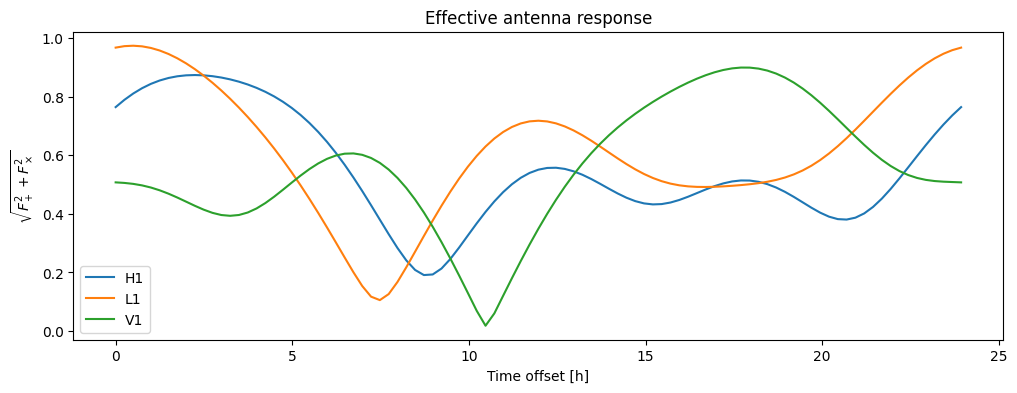

In [15]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:
    d = df_geometry[
        df_geometry["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        d["F_rss"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel(r"$\sqrt{F_+^2 + F_\times^2}$")
plt.title("Effective antenna response")
plt.legend()
plt.show()

## 8. Detector time delays

The geocentric reference time also determines the arrival-time offsets

$$
\tau_I(t_{\rm geo}).
$$

These delays are small compared with the 4 s CNN input, but physically relevant because inter-detector timing encodes sky geometry.

The delay variation is therefore quantified independently from the antenna amplitudes.

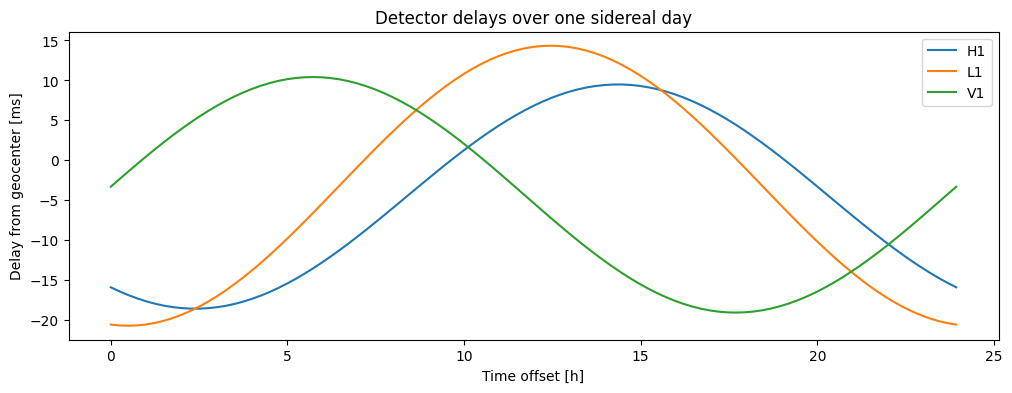

In [16]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:
    d = df_geometry[
        df_geometry["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        1e3 * d["delay_s"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel("Delay from geocenter [ms]")
plt.title("Detector delays over one sidereal day")
plt.legend()
plt.show()

## 9. Inter-detector timing geometry

For parameter inference, relative arrival times are often more informative than absolute geocentric delays.

We therefore compute

$$
\Delta\tau_{HL}=\tau_H-\tau_L,
$$

$$
\Delta\tau_{HV}=\tau_H-\tau_V,
$$

$$
\Delta\tau_{LV}=\tau_L-\tau_V.
$$

In [17]:
df_delay_pivot = (
    df_geometry
    .pivot(
        index="time_offset_h",
        columns="ifo",
        values="delay_s",
    )
    .reset_index()
)

df_delay_pivot["H1-L1_ms"] = (
    1e3
    * (
        df_delay_pivot["H1"]
        - df_delay_pivot["L1"]
    )
)

df_delay_pivot["H1-V1_ms"] = (
    1e3
    * (
        df_delay_pivot["H1"]
        - df_delay_pivot["V1"]
    )
)

df_delay_pivot["L1-V1_ms"] = (
    1e3
    * (
        df_delay_pivot["L1"]
        - df_delay_pivot["V1"]
    )
)

df_delay_pivot.head()

ifo,time_offset_h,H1,L1,V1,H1-L1_ms,H1-V1_ms,L1-V1_ms
0,0.000000,-0.015890,-0.020552,-0.003299,4.662283,-12.590237,-17.252520
1,0.249317,-0.016404,-0.020661,-0.002340,4.256725,-14.063816,-18.320540
2,0.498635,-0.016867,-0.020695,-0.001389,3.827130,-15.478107,-19.305237
3,0.747952,-0.017278,-0.020654,-0.000451,3.375338,-16.827055,-20.202393
4,0.997270,-0.017634,-0.020538,0.000471,2.903284,-18.104883,-21.008166


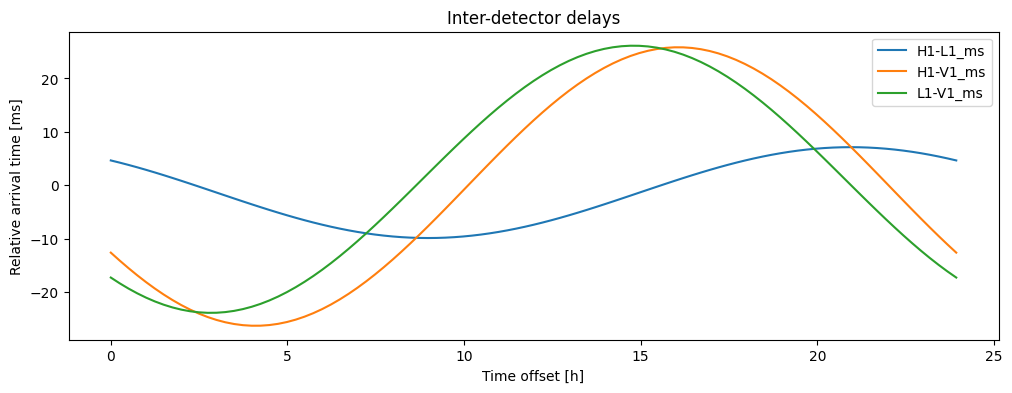

In [18]:
plt.figure(figsize=(12, 4))

for col in [
    "H1-L1_ms",
    "H1-V1_ms",
    "L1-V1_ms",
]:
    plt.plot(
        df_delay_pivot["time_offset_h"],
        df_delay_pivot[col],
        label=col,
    )

plt.xlabel("Time offset [h]")
plt.ylabel("Relative arrival time [ms]")
plt.title("Inter-detector delays")
plt.legend()
plt.show()

In [19]:
df_geometry_summary = (
    df_geometry
    .groupby("ifo")
    .agg(
        Fplus_min=("F_plus", "min"),
        Fplus_max=("F_plus", "max"),
        Fcross_min=("F_cross", "min"),
        Fcross_max=("F_cross", "max"),
        Frss_min=("F_rss", "min"),
        Frss_max=("F_rss", "max"),
        delay_min_ms=(
            "delay_s",
            lambda x: 1e3 * x.min(),
        ),
        delay_max_ms=(
            "delay_s",
            lambda x: 1e3 * x.max(),
        ),
    )
    .reset_index()
)

df_geometry_summary

,ifo,Fplus_min,Fplus_max,Fcross_min,Fcross_max,Frss_min,Frss_max,delay_min_ms,delay_max_ms
0,H1,-0.552644,0.770926,-0.409902,0.809190,0.191056,0.873274,-18.557005,9.487421
1,L1,-0.502138,0.650779,-0.972049,0.079734,0.105607,0.973266,-20.694608,14.337990
2,V1,-0.876129,0.425750,-0.452691,0.644337,0.018262,0.898780,-19.050774,10.418415


## 10. Sidereal-period consistency check

The first and last points differ by one sidereal day.

For the same source coordinates and polarization, the detector geometry should therefore return approximately to the same configuration.

We compare the antenna factors and delays at

$$
t_0
$$

and

$$
t_0 + T_{\rm sidereal}.
$$

In [20]:
rows = []

for ifo in DETECTORS:

    d = (
        df_geometry[
            df_geometry["ifo"] == ifo
        ]
        .sort_values("time_offset_s")
    )

    first = d.iloc[0]
    last = d.iloc[-1]

    rows.append({
        "ifo": ifo,
        "delta_F_plus":
            last["F_plus"] - first["F_plus"],
        "delta_F_cross":
            last["F_cross"] - first["F_cross"],
        "delta_F_rss":
            last["F_rss"] - first["F_rss"],
        "delta_delay_s":
            last["delay_s"] - first["delay_s"],
    })

df_sidereal_check = pd.DataFrame(rows)

df_sidereal_check

,ifo,delta_F_plus,delta_F_cross,delta_F_rss,delta_delay_s
0,H1,-1.815394e-09,-8.728726e-10,-8.846875e-10,1.794780e-11
1,L1,1.697342e-09,3.237212e-10,-2.276310e-10,4.864477e-12
2,V1,-6.523123e-10,8.724884e-10,4.659351e-11,-3.203256e-11


## 11. Projected detector strain

The previous sections studied the geometric response directly.

We now project the same physical waveform at each geocentric time using the production `DetectorProjector`.

Because `Detector.project_wave(..., method="lal")` applies both antenna response and physical detector delay, this test connects the geometric quantities above to the actual synthetic detector strain used by the simulation pipeline.

In [21]:
projection_rows = []
projections = {}

for offset, t_geo in zip(
    time_offsets,
    geocentric_times,
):

    projected = projector.project(
        h_plus=waveform.h_plus,
        h_cross=waveform.h_cross,
        parameters=params,
        geocentric_coalescence_time=t_geo,
    )

    projections[offset] = projected

    for ifo in DETECTORS:

        x = np.asarray(
            projected.strains[ifo],
            dtype=np.float64,
        )

        projection_rows.append({
            "time_offset_s": offset,
            "time_offset_h": offset / 3600.0,
            "ifo": ifo,
            "peak_abs":
                np.max(np.abs(x)),
            "rms":
                np.sqrt(np.mean(x**2)),
            "l2":
                np.linalg.norm(x),
        })

df_projection = pd.DataFrame(
    projection_rows
)

df_projection.head()

,time_offset_s,time_offset_h,ifo,peak_abs,rms,l2
0,0.000000,0.000000,H1,5.805442e-22,1.629936e-22,6.531957e-21
1,0.000000,0.000000,L1,7.397562e-22,2.063813e-22,8.270718e-21
2,0.000000,0.000000,V1,4.315586e-22,1.214487e-22,4.865534e-21
3,897.542609,0.249317,H1,6.015371e-22,1.685968e-22,6.756507e-21
4,897.542609,0.249317,L1,7.392490e-22,2.073754e-22,8.310555e-21


## 12. Time dependence of projected signal amplitude

If the changing antenna geometry is propagated correctly into the synthetic strain, the projected signal amplitude should vary with geocentric time even though the source-frame waveform, distance and orientation remain fixed.

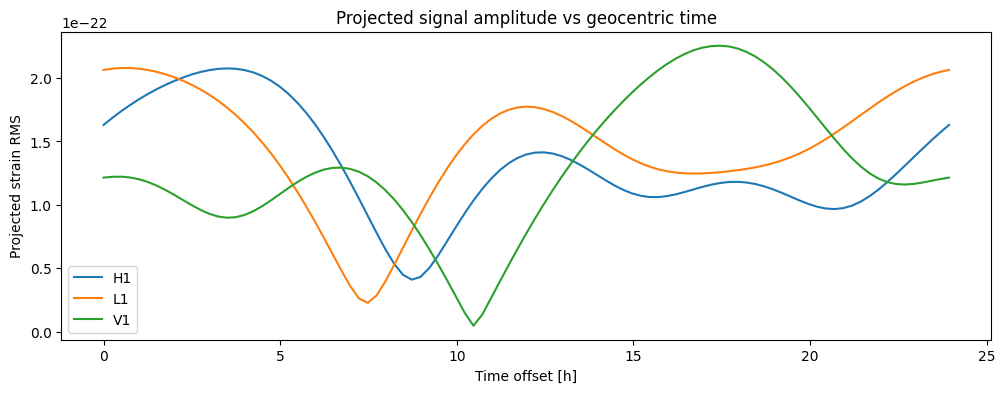

In [22]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:

    d = df_projection[
        df_projection["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        d["rms"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel("Projected strain RMS")
plt.title("Projected signal amplitude vs geocentric time")
plt.legend()
plt.show()

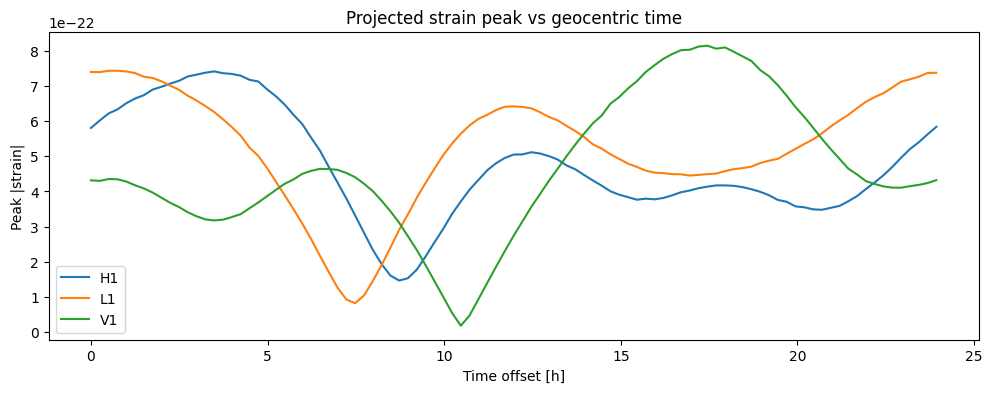

In [23]:
plt.figure(figsize=(12, 4))

for ifo in DETECTORS:

    d = df_projection[
        df_projection["ifo"] == ifo
    ]

    plt.plot(
        d["time_offset_h"],
        d["peak_abs"],
        label=ifo,
    )

plt.xlabel("Time offset [h]")
plt.ylabel("Peak |strain|")
plt.title("Projected strain peak vs geocentric time")
plt.legend()
plt.show()

In [25]:
df_response = df_geometry.merge(
    df_projection,
    on=[
        "time_offset_s",
        "time_offset_h",
        "ifo",
    ],
)

df_response[
    [
        "time_offset_h",
        "ifo",
        "F_plus",
        "F_cross",
        "F_rss",
        "rms",
        "peak_abs",
    ]
].head()

,time_offset_h,ifo,F_plus,F_cross,F_rss,rms,peak_abs
0,0.000000,H1,0.004979,0.763893,0.763909,1.629936e-22,5.805442e-22
1,0.000000,L1,0.054440,-0.965273,0.966807,2.063813e-22,7.397562e-22
2,0.000000,V1,0.392857,0.320804,0.507199,1.214487e-22,4.315586e-22
3,0.249317,H1,0.060678,0.786473,0.788811,1.685968e-22,6.015371e-22
4,0.249317,L1,0.003086,-0.971830,0.971835,2.073754e-22,7.392490e-22


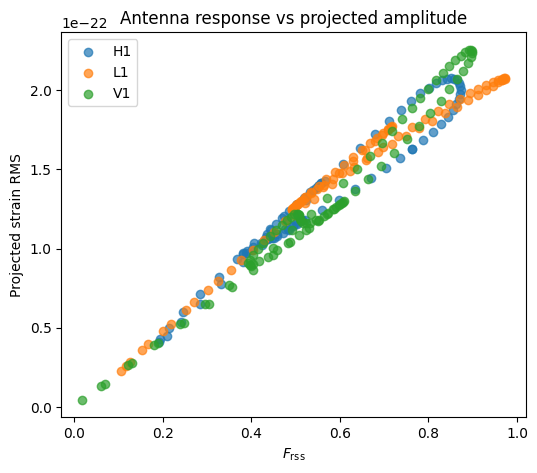

In [26]:
plt.figure(figsize=(6, 5))

for ifo in DETECTORS:

    d = df_response[
        df_response["ifo"] == ifo
    ]

    plt.scatter(
        d["F_rss"],
        d["rms"],
        label=ifo,
        alpha=0.7,
    )

plt.xlabel(r"$F_{\rm rss}$")
plt.ylabel("Projected strain RMS")
plt.title("Antenna response vs projected amplitude")
plt.legend()
plt.show()

We shouldn't expect perfect correlation. For a inclined source: 

$$
h_+ \neq h_{\times}
$$

in fact, the real combination is

$$
F_+h_+ + F_{\times}h_{\times}
$$

## 13. Interpretation boundary

A strong time dependence for a **fixed sky position** demonstrates that geocentric time is physically relevant.

However, this alone does not prove that the M10 training population has an artificially narrow antenna-response distribution.

M10 samples right ascension across the sky. Since Earth rotation effectively changes the detector orientation relative to right ascension, uniform sampling in RA may already reproduce much of the marginal antenna-response variability even at fixed geocentric time.

Therefore two distinct statements must be separated:

1. **event-level realism:** assigning the same geocentric time to every event is physically artificial;
2. **population-level distribution:** it remains to be tested whether randomizing geocentric time materially broadens or changes the training-domain response distribution when RA is already random.

The next M11.2 experiment will address the second question explicitly.

# 14. M11.2-B — Population-level effect of geocentric-time sampling

The previous experiment demonstrated that geocentric time strongly affects the detector response for a **fixed source**.

However, the M10 source population already samples right ascension uniformly over

$$
\alpha\in[0,2\pi),
$$

with isotropic declination and uniform polarization.

Since Earth rotation mainly changes the relative angle between the detector network and source right ascension, a uniform RA distribution may already reproduce most of the marginal antenna-response variability even when all events share the same geocentric time.

We therefore compare two populations:

**B1 — fixed-time population**

$$
\alpha_i,\delta_i,\psi_i\sim p_{\rm M10},
\qquad
t_{{\rm geo},i}=t_0.
$$

**B2 — variable-time population**

The exact same sky realizations are used, but

$$
t_{{\rm geo},i}
=
t_0 + u_i T_{\rm sidereal},
\qquad
u_i\sim U(0,1).
$$

The experiment tests whether geocentric-time randomization changes the *population distribution* of detector responses, rather than only individual events.

## 15. Expected result

For uniform right ascension, the marginal antenna-pattern distributions are expected to be approximately invariant under an independent shift in sidereal phase.

Therefore the null hypothesis for M11.2-B is:

$$
p(F_+,F_\times,\tau\mid t_{\rm geo}=t_0)
\approx
p(F_+,F_\times,\tau\mid t_{\rm geo}\sim U).
$$

A failure to find a large population-level difference would **not** imply that variable geocentric time is unnecessary.

It would instead indicate that:

- M10 already captures much of the marginal geometric diversity through random RA;
- variable time mainly improves event-level physical realism;
- the distinction becomes especially important when synthetic signals are coupled to real detector data at a specific GPS time.

In [28]:
N_POP = 20_000
POP_SEED = 2026

rng = np.random.default_rng(POP_SEED)

ra_pop = rng.uniform(
    0.0,
    2.0 * np.pi,
    N_POP,
)

dec_pop = np.arcsin(
    rng.uniform(
        -1.0,
        1.0,
        N_POP,
    )
)

psi_pop = rng.uniform(
    0.0,
    2.0 * np.pi,
    N_POP,
)

time_offsets_pop = rng.uniform(
    0.0,
    SIDEREAL_DAY,
    N_POP,
)

t_fixed = np.full(
    N_POP,
    T0,
)

t_variable = (
    T0 + time_offsets_pop
)

## 16. Population sanity checks

The two populations must share exactly the same sky coordinates and polarization.

The only changed variable is geocentric time.

In [29]:
print("N population:", N_POP)

print(
    "RA range:",
    ra_pop.min(),
    ra_pop.max(),
)

print(
    "Dec range:",
    dec_pop.min(),
    dec_pop.max(),
)

print(
    "Psi range:",
    psi_pop.min(),
    psi_pop.max(),
)

print(
    "Variable time span [h]:",
    (
        t_variable.max()
        - t_variable.min()
    ) / 3600.0,
)

N population: 20000
RA range: 0.0011587224991163611 6.282911530533719
Dec range: -1.5615689354756044 1.5557554200151626
Psi range: 0.00016024878340488492 6.283159740897861
Variable time span [h]: 23.93015691757202


In [30]:
def evaluate_geometry_population(
    ra,
    dec,
    psi,
    times,
    detector_objects,
):
    rows = []

    for i in range(len(ra)):

        for ifo, detector in detector_objects.items():

            fp, fc = detector.antenna_pattern(
                right_ascension=ra[i],
                declination=dec[i],
                polarization=psi[i],
                t_gps=times[i],
            )

            delay = detector.time_delay_from_earth_center(
                right_ascension=ra[i],
                declination=dec[i],
                t_gps=times[i],
            )

            rows.append({
                "sample": i,
                "ifo": ifo,
                "F_plus": float(fp),
                "F_cross": float(fc),
                "F_rss": float(
                    np.sqrt(fp**2 + fc**2)
                ),
                "delay_s": float(delay),
            })

    return pd.DataFrame(rows)

In [31]:
df_fixed = evaluate_geometry_population(
    ra=ra_pop,
    dec=dec_pop,
    psi=psi_pop,
    times=t_fixed,
    detector_objects=detector_objects,
)

df_variable = evaluate_geometry_population(
    ra=ra_pop,
    dec=dec_pop,
    psi=psi_pop,
    times=t_variable,
    detector_objects=detector_objects,
)

df_fixed["time_policy"] = "fixed"
df_variable["time_policy"] = "variable"

df_pop = pd.concat(
    [df_fixed, df_variable],
    ignore_index=True,
)

df_pop.head()

,sample,ifo,F_plus,F_cross,F_rss,delay_s,time_policy
0,0,H1,-0.455534,-0.377257,0.591468,-0.010628,fixed
1,0,L1,0.531151,0.655767,0.843890,-0.017687,fixed
2,0,V1,-0.361254,0.029062,0.362421,-0.000759,fixed
3,1,H1,-0.703571,0.545525,0.890286,0.018891,fixed
4,1,L1,0.789614,-0.613548,0.999965,0.021256,fixed


## 17. Marginal detector-response distributions

We first compare the one-dimensional distributions of

$$
F_+,\qquad
F_\times,\qquad
F_{\rm rss},\qquad
\tau.
$$

If uniform RA already absorbs the effect of sidereal phase at population level, their summary statistics should be nearly identical between fixed-time and variable-time populations.

In [32]:
summary_cols = [
    "F_plus",
    "F_cross",
    "F_rss",
    "delay_s",
]

df_pop_summary = (
    df_pop
    .groupby(
        ["time_policy", "ifo"]
    )[summary_cols]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max",
    ])
)

df_pop_summary

F_plus                                           F_cross  \
                     mean       std       min    median       max      mean   
time_policy ifo                                                               
fixed       H1   0.000160  0.446134 -0.998197  0.001853  0.996689 -0.001268   
            L1  -0.001494  0.446674 -0.992206  0.001217  0.998111 -0.001675   
            V1   0.001661  0.450995 -0.994223  0.000744  0.999381  0.003138   
variable    H1  -0.000775  0.449196 -0.995903 -0.000532  0.996973  0.005249   
            L1  -0.000246  0.447597 -0.997095  0.000940  0.994847 -0.006562   
            V1  -0.005310  0.446424 -0.998933 -0.007675  0.995008 -0.001422   

                                                            F_rss            \
                      std       min    median       max      mean       std   
time_policy ifo                                                               
fixed       H1   0.444368 -0.990760 -0.010489  0.997862  0.590060  0.219800   
            L1   0.444801 -0.996773  0.000631  0.997062  0.590878  0.219581   
            V1   0.446250 -0.998439  0.004244  0.997829  0.595325  0.219360   
variable    H1   0.446105 -0.997389  0.007017  0.997736  0.593788  0.219574   
            L1   0.446584 -0.996668 -0.006354  0.998933  0.593090  0.219204   
            V1   0.448999 -0.999187  0.000151  0.998019  0.594150  0.218843   

                                                delay_s                      \
                      min    median       max      mean       std       min   
time_policy ifo                                                               
fixed       H1   0.004456  0.576022  0.999962  0.000177  0.012185 -0.021236   
            L1   0.004124  0.574801  0.999965  0.000096  0.012223 -0.021255   
            V1   0.007524  0.577710  0.999969  0.000086  0.012320 -0.021239   
variable    H1   0.001473  0.577870  0.999988  0.000168  0.012284 -0.021238   
            L1   0.001408  0.575287  0.999988  0.000126  0.012271 -0.021256   
            V1   0.007936  0.576393  0.999946  0.000146  0.012275 -0.021236   

                                     
                   median       max  
time_policy ifo                      
fixed       H1   0.000223  0.021238  
            L1   0.000155  0.021256  
            V1   0.000205  0.021240  
variable    H1   0.000231  0.021237  
            L1   0.000226  0.021257  
            V1   0.000234  0.021240

In [33]:
quantiles = [
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99,
]

rows = []

for policy in [
    "fixed",
    "variable",
]:

    for ifo in DETECTORS:

        d = df_pop[
            (df_pop["time_policy"] == policy)
            & (df_pop["ifo"] == ifo)
        ]

        for variable in [
            "F_plus",
            "F_cross",
            "F_rss",
            "delay_s",
        ]:

            q = d[variable].quantile(
                quantiles
            )

            for quantile, value in q.items():

                rows.append({
                    "time_policy": policy,
                    "ifo": ifo,
                    "variable": variable,
                    "quantile": quantile,
                    "value": value,
                })

df_quantiles = pd.DataFrame(rows)

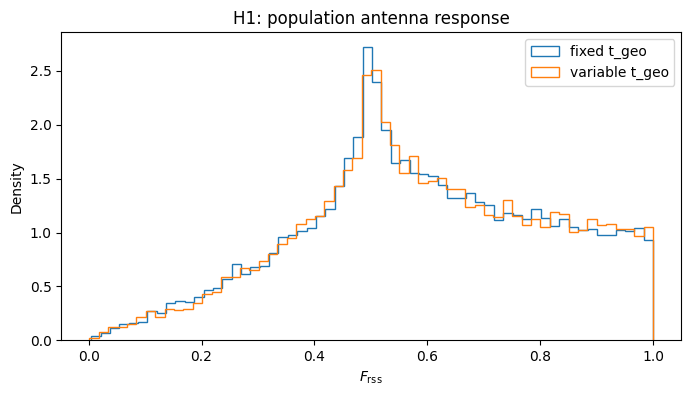

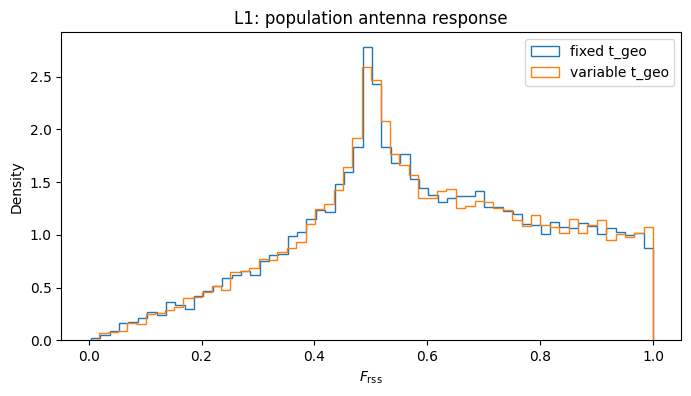

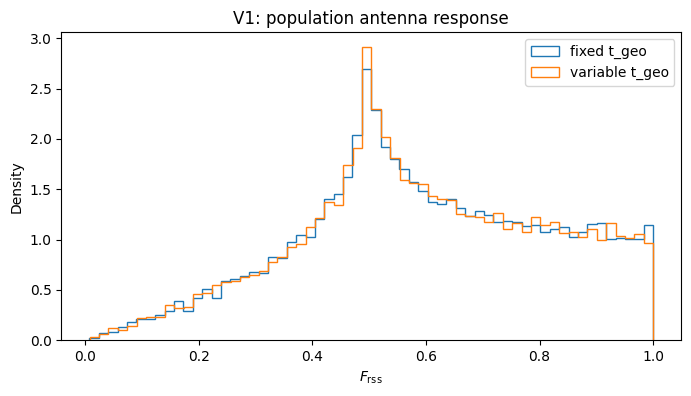

In [34]:
for ifo in DETECTORS:

    fixed = df_fixed[
        df_fixed["ifo"] == ifo
    ]["F_rss"]

    variable = df_variable[
        df_variable["ifo"] == ifo
    ]["F_rss"]

    plt.figure(figsize=(8, 4))

    plt.hist(
        fixed,
        bins=60,
        density=True,
        histtype="step",
        label="fixed t_geo",
    )

    plt.hist(
        variable,
        bins=60,
        density=True,
        histtype="step",
        label="variable t_geo",
    )

    plt.xlabel(r"$F_{\rm rss}$")
    plt.ylabel("Density")
    plt.title(
        f"{ifo}: population antenna response"
    )
    plt.legend()
    plt.show()

## 18. Distribution-level comparison

Visual similarity alone is insufficient.

For each detector and geometric quantity we compute:

- the two-sample Kolmogorov-Smirnov statistic;
- the Wasserstein distance;
- differences in mean and standard deviation.

Because the sample size is large, very small discrepancies can produce small KS p-values. Therefore the **effect size** is more important here than the p-value alone.

In [35]:
from scipy.stats import (
    ks_2samp,
    wasserstein_distance,
)

In [36]:
rows = []

for ifo in DETECTORS:

    d_fixed = df_fixed[
        df_fixed["ifo"] == ifo
    ]

    d_variable = df_variable[
        df_variable["ifo"] == ifo
    ]

    for variable in [
        "F_plus",
        "F_cross",
        "F_rss",
        "delay_s",
    ]:

        x = d_fixed[variable].to_numpy()
        y = d_variable[variable].to_numpy()

        ks = ks_2samp(
            x,
            y,
        )

        rows.append({
            "ifo": ifo,
            "variable": variable,

            "mean_fixed":
                np.mean(x),

            "mean_variable":
                np.mean(y),

            "delta_mean":
                np.mean(y)
                - np.mean(x),

            "std_fixed":
                np.std(x),

            "std_variable":
                np.std(y),

            "delta_std":
                np.std(y)
                - np.std(x),

            "ks_statistic":
                ks.statistic,

            "ks_pvalue":
                ks.pvalue,

            "wasserstein":
                wasserstein_distance(
                    x,
                    y,
                ),
        })

df_distribution_tests = pd.DataFrame(
    rows
)

df_distribution_tests

,ifo,variable,mean_fixed,mean_variable,delta_mean,std_fixed,std_variable,delta_std,ks_statistic,ks_pvalue,wasserstein
0,H1,F_plus,0.000160,-0.000775,-0.000935,0.446123,0.449185,0.003061,0.00595,0.868679,0.003398
1,H1,F_cross,-0.001268,0.005249,0.006518,0.444357,0.446094,0.001737,0.01250,0.087134,0.007081
2,H1,F_rss,0.590060,0.593788,0.003728,0.219795,0.219569,-0.000226,0.00965,0.307460,0.003842
3,H1,delay_s,0.000177,0.000168,-0.000009,0.012185,0.012284,0.000099,0.00685,0.733316,0.000120
4,L1,F_plus,-0.001494,-0.000246,0.001248,0.446663,0.447585,0.000923,0.00680,0.741513,0.003435
5,L1,F_cross,-0.001675,-0.006562,-0.004886,0.444790,0.446573,0.001783,0.01020,0.247496,0.005275
6,L1,F_rss,0.590878,0.593090,0.002212,0.219575,0.219198,-0.000377,0.00635,0.812357,0.002305
7,L1,delay_s,0.000096,0.000126,0.000030,0.012222,0.012270,0.000048,0.00570,0.899445,0.000071
8,V1,F_plus,0.001661,-0.005310,-0.006971,0.450984,0.446412,-0.004571,0.01165,0.131418,0.007522
9,V1,F_cross,0.003138,-0.001422,-0.004561,0.446239,0.448988,0.002749,0.00915,0.370139,0.005358


## 19. Network-level antenna response

Even if individual detector marginals are unchanged, geocentric-time sampling could in principle modify correlations between detector responses.

We therefore define a simple network response magnitude

$$
F_{\rm net}
=
\sqrt{
F_{H1}^2+
F_{L1}^2+
F_{V1}^2
},
$$

where each detector contribution is

$$
F_I =
\sqrt{F_{+,I}^2+F_{\times,I}^2}.
$$

In [37]:
def build_network_response(df):

    pivot = (
        df
        .pivot(
            index="sample",
            columns="ifo",
            values="F_rss",
        )
    )

    pivot["F_network"] = np.sqrt(
        pivot["H1"]**2
        + pivot["L1"]**2
        + pivot["V1"]**2
    )

    return pivot.reset_index()

In [38]:
net_fixed = build_network_response(
    df_fixed
)

net_variable = build_network_response(
    df_variable
)

net_fixed["time_policy"] = "fixed"
net_variable["time_policy"] = "variable"

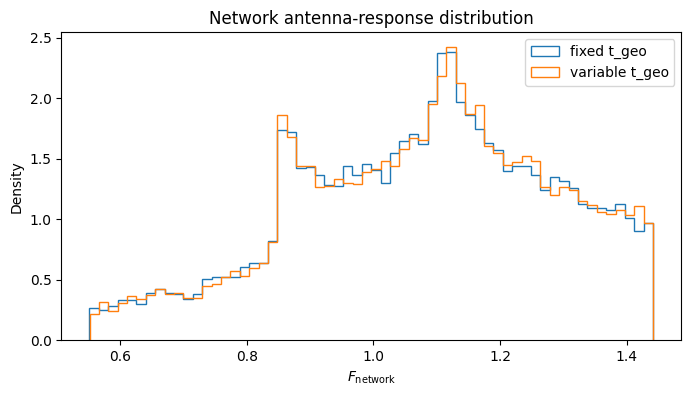

In [39]:
plt.figure(figsize=(8, 4))

plt.hist(
    net_fixed["F_network"],
    bins=60,
    density=True,
    histtype="step",
    label="fixed t_geo",
)

plt.hist(
    net_variable["F_network"],
    bins=60,
    density=True,
    histtype="step",
    label="variable t_geo",
)

plt.xlabel(r"$F_{\rm network}$")
plt.ylabel("Density")
plt.title("Network antenna-response distribution")
plt.legend()
plt.show()

In [40]:
x = net_fixed["F_network"].to_numpy()
y = net_variable["F_network"].to_numpy()

ks_net = ks_2samp(x, y)

df_network_test = pd.DataFrame({
    "metric": [
        "mean",
        "std",
        "KS statistic",
        "KS p-value",
        "Wasserstein",
    ],
    "fixed_or_value": [
        np.mean(x),
        np.std(x),
        ks_net.statistic,
        ks_net.pvalue,
        wasserstein_distance(x, y),
    ],
    "variable": [
        np.mean(y),
        np.std(y),
        np.nan,
        np.nan,
        np.nan,
    ],
})

df_network_test

,metric,fixed_or_value,variable
0,mean,1.074553,1.076914
1,std,0.204195,0.204347
2,KS statistic,0.010150,NaN
3,KS p-value,0.252562,NaN
4,Wasserstein,0.002451,NaN


In [41]:
def build_pairwise_delays(df):

    pivot = (
        df
        .pivot(
            index="sample",
            columns="ifo",
            values="delay_s",
        )
    )

    pivot["H1-L1_ms"] = (
        1e3
        * (
            pivot["H1"]
            - pivot["L1"]
        )
    )

    pivot["H1-V1_ms"] = (
        1e3
        * (
            pivot["H1"]
            - pivot["V1"]
        )
    )

    pivot["L1-V1_ms"] = (
        1e3
        * (
            pivot["L1"]
            - pivot["V1"]
        )
    )

    return pivot.reset_index()

In [42]:
delay_fixed = build_pairwise_delays(
    df_fixed
)

delay_variable = build_pairwise_delays(
    df_variable
)

In [43]:
delay_cols = [
    "H1-L1_ms",
    "H1-V1_ms",
    "L1-V1_ms",
]

rows = []

for col in delay_cols:

    x = delay_fixed[col].to_numpy()
    y = delay_variable[col].to_numpy()

    ks = ks_2samp(x, y)

    rows.append({
        "pair": col,
        "mean_fixed": np.mean(x),
        "mean_variable": np.mean(y),
        "std_fixed": np.std(x),
        "std_variable": np.std(y),
        "ks_statistic": ks.statistic,
        "ks_pvalue": ks.pvalue,
        "wasserstein_ms":
            wasserstein_distance(
                x,
                y,
            ),
    })

df_pairwise_delay_tests = pd.DataFrame(
    rows
)

df_pairwise_delay_tests

,pair,mean_fixed,mean_variable,std_fixed,std_variable,ks_statistic,ks_pvalue,wasserstein_ms
0,H1-L1_ms,0.081307,0.042237,5.790898,5.759480,0.00760,0.607577,0.054511
1,H1-V1_ms,0.091219,0.022436,15.673207,15.787894,0.00820,0.509336,0.164029
2,L1-V1_ms,0.009913,-0.019801,15.221163,15.324661,0.00655,0.781630,0.126079


## 20. Event-level change despite population-level invariance

Population-level equivalence does not imply event-level equivalence.

Because B1 and B2 use the same sky realization for every sample, we can directly quantify the change produced by assigning a different geocentric time to that same event.

This distinguishes:

- **distributional diversity**, which may already be captured by random RA;
- **event-level physical coherence**, which requires the correct geocentric time.

In [44]:
paired = df_fixed.merge(
    df_variable,
    on=[
        "sample",
        "ifo",
    ],
    suffixes=(
        "_fixed",
        "_variable",
    ),
)

paired["delta_F_rss"] = (
    paired["F_rss_variable"]
    - paired["F_rss_fixed"]
)

paired["abs_delta_F_rss"] = np.abs(
    paired["delta_F_rss"]
)

paired["delta_delay_ms"] = (
    1e3
    * (
        paired["delay_s_variable"]
        - paired["delay_s_fixed"]
    )
)

In [45]:
df_event_level_summary = (
    paired
    .groupby("ifo")
    .agg(
        median_abs_delta_F=(
            "abs_delta_F_rss",
            "median",
        ),
        q90_abs_delta_F=(
            "abs_delta_F_rss",
            lambda x: np.quantile(x, 0.90),
        ),
        max_abs_delta_F=(
            "abs_delta_F_rss",
            "max",
        ),
        median_abs_delta_delay_ms=(
            "delta_delay_ms",
            lambda x: np.median(np.abs(x)),
        ),
        q90_abs_delta_delay_ms=(
            "delta_delay_ms",
            lambda x: np.quantile(
                np.abs(x),
                0.90,
            ),
        ),
    )
    .reset_index()
)

df_event_level_summary

,ifo,median_abs_delta_F,q90_abs_delta_F,max_abs_delta_F,median_abs_delta_delay_ms,q90_abs_delta_delay_ms
0,H1,0.200890,0.496702,0.963962,7.619261,21.146409
1,L1,0.207668,0.512498,0.938456,9.492244,26.162492
2,V1,0.197861,0.504712,0.965669,7.967862,21.999313


# 21. M11.2-B interpretation

This experiment separates two questions that are easy to conflate.

### Population-level diversity

If the fixed-time and variable-time distributions of antenna responses and detector delays are nearly identical, this indicates that uniform RA sampling already provides most of the marginal geometric diversity present in the synthetic population.

### Event-level realism

The paired comparison measures a different quantity: whether the *same physical source* would be projected differently when assigned a different geocentric time.

Substantial paired changes together with nearly identical marginal distributions would imply:

> randomizing geocentric time does not necessarily broaden the overall synthetic geometry distribution, but it restores the correct physical association between source coordinates, detector orientation and arrival-time geometry.

This distinction will guide the final M11 simulation policy.

## 22. M11.2 final decision

M11.2 shows that geocentric time has a strong effect at the individual-event level but only a very small effect on the marginal population geometry when right ascension is already sampled uniformly.

The fixed-time M10 population therefore does not appear to suffer from a major loss of antenna-response diversity. However, assigning the same GPS time to every event is still physically artificial because it breaks the event-level association between sky coordinates and detector orientation.

### Decision

No permanent change to the synthetic `DatasetBuilder` time-sampling policy is introduced at this stage.

The existing explicit `geocentric_coalescence_time` interface is sufficient for the next experiments.

When real off-source noise is introduced, the synthetic signal must use the physical GPS time associated with the selected real-noise window:

$$
t_{\rm geo} = t_{\rm GPS,noise}.
$$

This preserves coherence between antenna response, detector delays, detector state, PSD and real strain.

Random geocentric-time sampling for purely Gaussian synthetic datasets remains an optional realism improvement, but M11.2 provides no evidence that it is required to recover the marginal detector-geometry distribution.